<a href="https://colab.research.google.com/github/JCMiller71/sprint-4-project/blob/main/JC_Miller_sprint4_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 4 Project: E-Commerce Customer Behavior EDA

Welcome to your Sprint 4 final project. In this project, you will apply everything you've learned across Sprints 1–4 to perform a complete Exploratory Data Analysis on the **Olist Brazilian E-Commerce dataset** — real data from a real e-commerce platform.


## Dataset

You'll work with 7 CSV files from the Olist e-commerce dataset:

| File | Rows | Description |
|---|---|---|
| `olist_orders_dataset.csv` | 99,441 | Orders with timestamps and status |
| `olist_order_items_dataset.csv` | 112,650 | Items per order with price and freight |
| `olist_customers_dataset.csv` | 99,441 | Customer ID, city, state |
| `olist_products_dataset.csv` | 32,951 | Products with category and dimensions |
| `olist_order_reviews_dataset.csv` | 99,224 | Review scores (1–5 stars) |
| `olist_order_payments_dataset.csv` | 103,886 | Payment type and value |
| `product_category_name_translation.csv` | 71 | Portuguese → English category names |

Let's get started!

---

## Setup

Run the cells below to import the libraries you'll need and load the datasets. The data is hosted on GitHub, so you can load it with one line of code per file — no uploads required.

In [ ]:
# Import libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Confirm versions
print(f"pandas version: {pd.__version__}")
print("Setup complete!")

pandas version: 2.2.2
Setup complete!


In [ ]:
# Load the 7 datasets from the curriculum GitHub repo
BASE_URL = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analytics/eda-project/'

orders = pd.read_csv(BASE_URL + 'olist_orders_dataset.csv')
items = pd.read_csv(BASE_URL + 'olist_order_items_dataset.csv')
customers = pd.read_csv(BASE_URL + 'olist_customers_dataset.csv')
products = pd.read_csv(BASE_URL + 'olist_products_dataset.csv')
reviews = pd.read_csv(BASE_URL + 'olist_order_reviews_dataset.csv')
payments = pd.read_csv(BASE_URL + 'olist_order_payments_dataset.csv')
translation = pd.read_csv(BASE_URL + 'product_category_name_translation.csv')

print(f"orders:      {orders.shape}")
print(f"items:       {items.shape}")
print(f"customers:   {customers.shape}")
print(f"products:    {products.shape}")
print(f"reviews:     {reviews.shape}")
print(f"payments:    {payments.shape}")
print(f"translation: {translation.shape}")

orders:      (99441, 8)
items:       (112650, 7)
customers:   (99441, 5)
products:    (32951, 9)
reviews:     (99224, 7)
payments:    (103886, 5)
translation: (71, 2)


In [ ]:
# Set up an in-memory SQLite database with all 7 tables
# This lets you run SQL queries directly against the DataFrames
conn = sqlite3.connect(':memory:')

orders.to_sql('orders', conn, index=False, if_exists='replace')
items.to_sql('items', conn, index=False, if_exists='replace')
customers.to_sql('customers', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')
reviews.to_sql('reviews', conn, index=False, if_exists='replace')
payments.to_sql('payments', conn, index=False, if_exists='replace')
translation.to_sql('translation', conn, index=False, if_exists='replace')

print("SQLite database ready. You can now run SQL queries with pd.read_sql().")

SQLite database ready. You can now run SQL queries with pd.read_sql().


---

## Question 1: Inspect the orders DataFrame

**Your task:** For the `orders` DataFrame:
1. Print its shape
2. Print the first 5 rows with `.head()`
3. Print column info with `.info()`

This is the very first thing every analyst does with a new dataset.

*Skills: Sprint 4 Ch 01 (Pandas inspection)*

In [ ]:
print (orders.shape)
print (orders.head(5))
print (orders.info())

(99441, 8)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00       

---

## Question 2: Clean the orders data

The `orders` DataFrame has timestamp columns stored as strings, and a few have missing values.

**Your task:**
1. Use `.isnull().sum()` to count missing values in each column of `orders`
2. Convert `order_purchase_timestamp` and `order_delivered_customer_date` to datetime using `pd.to_datetime()`
3. Print the dtypes after conversion to verify

*Skills: Sprint 4 Ch 02 (Cleaning, dtype conversion)*

In [ ]:
order_count = orders.isnull().sum()
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
print(orders.dtypes)
print(order_count)

# 160 missing values in order_approved_at column
# 1783 missing values in order_delivered_carrier_date column
# 2965 missing values in order_delivered_customer_date column

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date            object
dtype: object
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


---

## Question 3: Order status breakdown (SQL)

**Your task:** Write a SQL query against the `orders` table that returns:
- `order_status`
- `num_orders` — count of orders with that status
- `pct` — percentage of total orders, rounded to 2 decimals

Sort by `num_orders` descending. Save the result to a DataFrame called `status_summary` and print it.

**Hint:** Use `pd.read_sql("...", conn)`. The percentage trick is `COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders)`.

*Skills: Sprint 2 (SQL aggregation), Sprint 4 Ch 03 (Descriptive stats)*

In [ ]:
query = '''
    SELECT
        order_status,
        COUNT(*) AS num_orders,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 2) AS pct
    FROM
        orders
    GROUP BY
        order_status
    ORDER BY
        num_orders DESC
'''
status_summary = pd.read_sql(query, conn)
print(status_summary)

# If this is current data, 97% delivered orders and less than 1% in other statuses
# This suggests no one is ordering

  order_status  num_orders    pct
0    delivered       96478  97.02
1      shipped        1107   1.11
2     canceled         625   0.63
3  unavailable         609   0.61
4     invoiced         314   0.32
5   processing         301   0.30
6      created           5   0.01
7     approved           2   0.00


---

## Question 4: Top 10 highest-revenue orders (SQL JOIN)

Each order can have multiple items. Total order revenue = sum of `price + freight_value` across all its items.

**Your task:** Write a SQL query that JOINs `orders` and `items` to find the **10 highest-revenue orders**. Return:
- `order_id`
- `order_status`
- `total_revenue` — rounded to 2 decimals

Save the result to `top_orders` and print it.

*Skills: Sprint 2 (SQL JOIN, GROUP BY), Sprint 4 Ch 06 (combining tables)*

In [ ]:
query = '''
    SELECT
        o.order_id,
        o.order_status,
        ROUND(SUM(i.price + i.freight_value), 2) AS total_revenue
    FROM
        orders o
    JOIN
        items i ON o.order_id = i.order_id
    GROUP BY
        o.order_id, o.order_status
    ORDER BY
        total_revenue DESC
    LIMIT 10
'''
top_orders = pd.read_sql(query, conn)
print(top_orders)

# High number of cancellations for one item in the top 10, but overall negligible number when considering overall revenue



                           order_id order_status  total_revenue
0  03caa2c082116e1d31e67e9ae3700499    delivered       13664.08
1  736e1922ae60d0d6a89247b851902527    delivered        7274.88
2  0812eb902a67711a1cb742b3cdaa65ae    delivered        6929.31
3  fefacc66af859508bf1a7934eab1e97f    delivered        6922.21
4  f5136e38d1a14a4dbd87dff67da82701    delivered        6726.66
5  2cc9089445046817a7539d90805e6e5a    delivered        6081.54
6  a96610ab360d42a2e5335a3998b4718a    delivered        4950.34
7  b4c4b76c642808cbe472a32b86cddc95     canceled        4809.44
8  199af31afc78c699f0dbf71fb178d4d4    delivered        4764.34
9  8dbc85d1447242f3b127dda390d56e19    delivered        4681.78


---

## Question 5: English product categories (pandas merge)

The `products` table has a Portuguese category column called `product_category_name`. The `translation` table maps each Portuguese name to its English equivalent.

**Your task:**
1. Use `products.merge(translation, on='product_category_name', how='left')` to add the English column. Save it to `products_eng`.
2. Find the **top 10 categories by number of products** using `value_counts()` on the `product_category_name_english` column. Save to `top_categories` and print it.

*Skills: Sprint 4 Ch 06 (pandas merge), Ch 03 (value_counts)*

In [ ]:
products_eng = products.merge(translation, on='product_category_name', how='left')
top_categories = products_eng['product_category_name_english'].value_counts().head(10)
print(top_categories)

product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64


---

## Question 6: Revenue and average review score by category

Now you'll combine three tables and compute multiple metrics per category.

**Your task:**
1. Build a DataFrame that merges `items` with `products_eng` (to get categories), then merges with `reviews` (to get scores). The shared key chain is: `items.product_id → products_eng.product_id` and `items.order_id → reviews.order_id`.
2. Add a `revenue` column = `price + freight_value`
3. Group by `product_category_name_english` and aggregate:
   - `total_revenue` = sum of `revenue`
   - `avg_review` = mean of `review_score`
   - `n_items` = count of `order_id`
4. Sort by `total_revenue` descending and show the **top 10 categories**. Save to `category_summary`.

*Skills: Sprint 4 Ch 05 (multi-table merge, groupby with multiple aggregations)*

In [ ]:
new_df = items.merge(products_eng, on='product_id', how='left').merge(reviews, on='order_id', how='left')
new_df['revenue'] = new_df['price'] + new_df['freight_value']
group_df = new_df.groupby('product_category_name_english').agg(
    total_revenue=('revenue','sum'),
    avg_review=('review_score', 'mean'),
    n_items=('order_id', 'count')
)
category_summary = group_df.sort_values(by='total_revenue', ascending=False).head(10)
print(category_summary)
# This result conflicts with the top selling english products in the last question, where the top selling categories were bed_bath_table, and sports and leisure items

                               total_revenue  avg_review  n_items
product_category_name_english                                    
health_beauty                     1446622.08    4.142768     9727
watches_gifts                     1306761.40    4.019160     6001
bed_bath_table                    1258189.51    3.895663    11270
sports_leisure                    1163329.98    4.107986     8700
computers_accessories             1068070.48    3.930819     7894
furniture_decor                    910683.05    3.903493     8415
housewares                         781170.03    4.055019     6989
cool_stuff                         721492.90    4.146341     3806
auto                               687374.19    4.065512     4256
garden_tools                       585646.54    4.042735     4361


---

## Question 7: Top 10 customer states (SQL + bar chart)

**Your task:**
1. Write a SQL query that returns the **top 10 customer states** by number of customers. Columns: `customer_state`, `num_customers`. Save to `state_top10`.
2. Create a **bar chart** of `num_customers` by `customer_state`. Add a title and rotate the x-tick labels if they overlap.

*Skills: Sprint 2 (SQL GROUP BY), Sprint 4 Ch 04 (bar chart)*

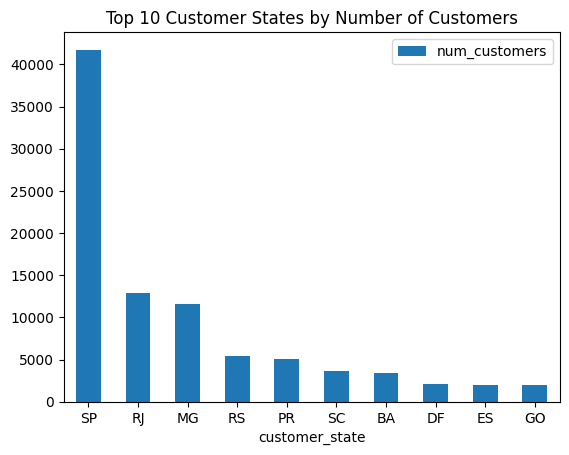

In [ ]:
query = '''
    SELECT
        c.customer_state,
        COUNT(DISTINCT c.customer_id) AS num_customers
    FROM
        customers c
    GROUP BY
        c.customer_state
    ORDER BY
        num_customers DESC
    LIMIT 10
'''
state_top10 = pd.read_sql(query, conn)
state_top10.plot(
      x = 'customer_state',
      y = 'num_customers',
      kind='bar',
      title='Top 10 Customer States by Number of Customers',
      rot=0
      )
plt.show()

# The Sao Paulo region has the highest amount of leads, with the highest amount of customers

---

## Question 8: Monthly order trend (line chart)

**Your task:**
1. From the cleaned `orders` DataFrame (with datetime columns from Q2), extract a `year_month` period from `order_purchase_timestamp` using `.dt.to_period('M')`
2. Count orders per month — save to a DataFrame called `monthly_orders` with columns `year_month` and `num_orders`
3. Plot a **line chart** of `num_orders` over time. Add a title.

**Hint:** `orders['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index()` is a fast way to get monthly counts. Convert the period index back to string for plotting.

*Skills: Sprint 4 Ch 02 (datetime), Ch 03 (groupby), Ch 04 (line chart)*

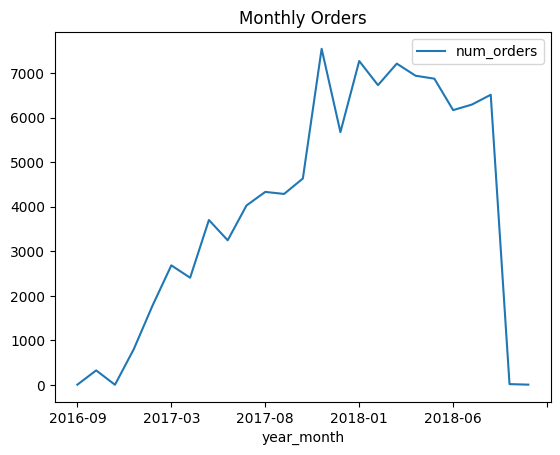

In [ ]:
monthly_counts_series = orders['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index()
monthly_orders = monthly_counts_series.reset_index()
monthly_orders.columns = ['year_month', 'num_orders']
monthly_orders['year_month'] = monthly_orders['year_month'].astype(str)
monthly_orders.plot(
    x='year_month',
    y='num_orders',
    kind='line',
    title='Monthly Orders'
)
plt.show()

---

## Question 9: Does delivery speed affect review scores?

This is a real business question: do customers who get their orders faster leave better reviews?

**Your task:**
1. From `orders`, keep only rows where `order_delivered_customer_date` is not null
2. Add a `delivery_days` column = (delivery date − purchase date) in days. **Hint:** subtract the two datetime columns and use `.dt.days`
3. Merge with `reviews` on `order_id` to get the `review_score` for each order
4. Compute the **correlation** between `delivery_days` and `review_score` using `.corr()`
5. Group by `review_score` and show the **average delivery days** for each score (1 through 5)
6. Plot a bar chart of average delivery days by review score

What pattern do you see? Add a markdown cell with your interpretation.

*Skills: Sprint 4 Ch 03 (correlation), Ch 04 (visualization), Ch 06 (merge + groupby)*

Correlation between delivery_days and review_score: -0.334

Average delivery days by review score:
review_score
1.0    20.849825
2.0    16.194832
3.0    13.795278
4.0    11.848054
5.0    10.224097
Name: delivery_days, dtype: float64


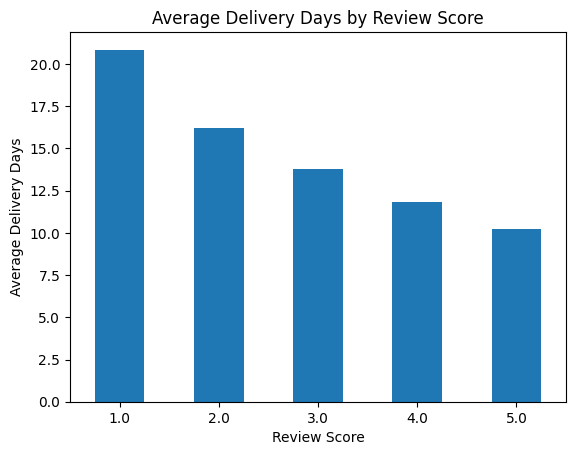

In [ ]:
orders_filtered = orders[orders['order_delivered_customer_date'].notnull()].copy()
orders_filtered['delivery_days'] = (orders_filtered['order_delivered_customer_date'] - orders_filtered['order_purchase_timestamp']).dt.days
merged_df = orders_filtered.merge(reviews, on='order_id', how='left')
correlation = merged_df['delivery_days'].corr(merged_df['review_score'])
print(f"Correlation between delivery_days and review_score: {correlation:.3f}")

# Group by review_score and show average delivery days
avg_delivery_days_by_review = merged_df.groupby('review_score')['delivery_days'].mean()
print("\nAverage delivery days by review score:")
print(avg_delivery_days_by_review)

# Plot a bar chart of average delivery days by review score
avg_delivery_days_by_review.plot(
    kind='bar',
    title='Average Delivery Days by Review Score',
    xlabel='Review Score',
    ylabel='Average Delivery Days',
    rot=0
)
plt.show()

**My interpretation:**

This chart implies two things: 1) people who recieve faster deliveries do, in fact, leave better reviews, but also, 2) that they are less likely to leave a review. The highest number of reviews overall is 1-star reviews given by those who recieved their orders after the longest amount of delivery days, while the lowest amount of reviews is 5-star reviews given after the shortest amount of delivery days. This result implies that customers who are satisfied with their delivery speed will likely either give a good review or no review at all.

---

## Question 10: Final Report

Write a **2–3 paragraph executive summary** of your findings as a markdown cell below. A good report answers:

- **What is the overall health of the business?** (Use Q3, Q8 — order volumes and trends)
- **Which product categories should we double down on?** (Use Q6 — revenue + review scores together)
- **Where are our customers and how do we serve them?** (Use Q7, Q9 — geography and delivery speed)
- **What is one specific recommendation you would make to the leadership team?**

Write as if you're presenting to a non-technical executive. Use plain language. Reference specific numbers from your analysis.

*Skills: Sprint 4 Ch 06 (analytical reporting)*


# **Executive Summary**

### Business Health

Looking at monthly orders from 2016 to 2018, this business is not in a healthy position. Monthly orders increased to a high of well over 7,000 at the end of 2017 before steadily dropping in the opening months of 2018. Then, following the summer of 2018, orders plummeted to 0 and do not show any signs of rising. A look at current order statuses sharpens this point. The number of orders delivered far exceeds the number of orders in any other status. Only 2 orders are approved and 5 created at this current moment, which tells us hardly anyone is buying from this business currently.

### Top Categories and Geography

The product categories that earn the most revenue and the highest reviews are as follows: 1) Health and Beauty products, 2) Watches and Gifts, 3) Bed/Bath and Table items. As such the team should focus on stocking more of these items because they are clearly what people buy and need the most. Most customers are buying in the SP state, followed by RJ and MG. Rather than doubling down on the one area where business is thriving, we should expand our focus to two to three other regions and market our products there to improve outreach.

### Delivery and Review Strategy

Customers satisfied by delivery speed tend to leave less reviews but the reviews they do leave tend to be better. So, we should maintain high delivery speed and encourage these customers to leave more reviews. One way to do this is by tailoring call to actions according to the quality of the item they receive, not just delivery speed.


### Recommendation

This business needs to improve its lead generation. The fact that their revenue is being generated primarily by only one region in comparison to all the others is a huge problem. The enormous drop in sales can be attributed to leads being exhausted in one area while ignoring all others. Health products and gifts are things that people will always buy, so we can't go wrong by marketing to more than one region. Simply maintain marketing infrasture in the area where it works, and shift that model to areas where revenue is not increasing.